# Proyecto 2: Detección de preguntas duplicadas

### Procesado del Lenguaje Natural

**Angel Navia Vázquez, Pablo Martínez Olmos**

  * 1.1 (January 2026) Revised and updated version

Departamento de Teoría de la Señal y Comunicaciones

**Universidad Carlos III de Madrid**

<img src='http://www.tsc.uc3m.es/~navia/figures/logo_uc3m_foot.jpg' width=400 />

AUTOR(ES):

-  **Sinelnik, Matvey**

En este segundo proyecto vamos a utilizar las parametrizaciones de palabras y textos que hemos visto durante el curso y las aplicaremos al problema de encontrar preguntas duplicadas en una base de datos real ([Quora Question Pairs](https://www.kaggle.com/c/quora-question-pairs/data)).

En este proyecto, **deberemos** utilizar **tres métodos distintos** para vectorizar cada una de las 10.000 preguntas:

- **TF-IDF** (elija las opciones que considere más adecuadas).

- **LSA** a partir del TF-IDF anterior (elija las opciones que considere más adecuadas).

- **Text embedding** de cada pregunta (elija las opciones que considere más adecuadas).


**OBJETIVO**: Para cada uno de los tres métodos de vectorización obtener la matriz de distancias entre los documentos y determinar la fracción de casos (precisión) en los que la pregunta duplicada **se encuentra entre los K resultados más cercanos**. Dibuje dicha precisión en función de $K$, para $K=1,\ldots,10$.

A continuación se proporciona un código base sobre el que hay que añadir las partes ausentes, marcadas con ``<INSERTAR CODIGO>``.

**IMPORTANTE, no modificar o eliminar el código proporcionado, el notebook debe ejecutar sin error y los resultados mostrados en pantalla y las gráficas deben ser los indicados.**

Los datos se proporcionan en el fichero **"QUORA_DUPLICATES_10000.csv"**, en el que la primera columna es el texto de la pregunta, y en la segunda columna hay un identificador para localizar preguntas duplicadas (hay dos frases que se consideran equivalentes o duplicadas y tienen en mismo identificador).

## Enfoque y justificación teórica

### Métodos utilizados (basados en las sesiones del curso)

**1. TF-IDF (sesiones 3 y 4):** Representación Term Frequency–Inverse Document Frequency. Como se explicó en la sesión 3, TF-IDF pondera cada término por su frecuencia en el documento y penaliza los términos que aparecen en muchos documentos (alta IDF = alta discriminación). Usamos n-gramas de palabras (1,2) y de caracteres (2,4) para capturar variaciones morfológicas y bigramas. Se filtran extremos con `min_df` y `max_df` como se vio en la sesión 3 (gestión del vocabulario). Se normaliza L2 para poder usar distancia coseno (sesión 3, sección 6.2).

**2. LSA (sesión 4):** Latent Semantic Analysis aplica la descomposición SVD a la matriz TF-IDF para obtener una representación de dimensión reducida. Como se explicó en la sesión 4, la matriz $\mathbf{A} \approx \mathbf{U} \cdot \mathbf{S} \cdot \mathbf{V}^T$ y cada documento se representa por su vector $\mathbf{g}_j$ en el espacio de dimensión $K$ (los "tópicos"). LSA captura relaciones semánticas latentes entre términos que comparten contextos similares.

**3. Text Embeddings (sesión 7):** Como se vio en la sesión 7 (sección 3.2), un enfoque para obtener el embedding de una frase es calcular la **media de los word embeddings** de sus tokens. Sin embargo, los modelos de **Sentence Transformers** están específicamente entrenados para producir embeddings de frases donde la similitud coseno refleja la similitud semántica. Usamos `all-mpnet-base-v2` (768 dimensiones), uno de los mejores modelos de Sentence Transformers para tareas de similitud semántica.

### Distancia coseno

Para los tres métodos, usamos la **distancia coseno** (sesión 3, sección 6.2), que mide la similitud entre vectores independientemente de su magnitud:

$$\text{cos}(\mathbf{v}_1, \mathbf{v}_2) = \frac{\mathbf{v}_1 \cdot \mathbf{v}_2}{\|\mathbf{v}_1\| \cdot \|\mathbf{v}_2\|}$$

Como se vio en la sesión 3, la distancia coseno es preferible a la euclídea para representaciones BoW/TF-IDF porque no depende de la longitud de los documentos.

In [1]:
import time
t_ini = time.time()

# Importe las demás librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# NLP - Preprocesado (sesión 2)
import spacy
nlp = spacy.load('en_core_web_sm', disable=['ner', 'parser'])

# Vectorización TF-IDF (sesión 3) y LSA (sesión 4)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_distances

# Embeddings (sesión 7)
import torch
from sentence_transformers import SentenceTransformer

# Detección de dispositivo — Apple Silicon M2 Pro usa MPS (Metal Performance Shaders)
if torch.backends.mps.is_available():
    DEVICE = 'mps'
elif torch.cuda.is_available():
    DEVICE = 'cuda'
else:
    DEVICE = 'cpu'

print(f"Device: {DEVICE}")
print("Librerías cargadas ✓")

Device: mps
Librerías cargadas ✓


In [2]:
# Lectura del CSV: cada línea tiene formato "texto_pregunta,id"
import csv

preguntas = []
ids = []

with open('Proyecto2QuoraDataset/QUORA_DUPLICATES_10000.csv', 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    for row in reader:
        # La última columna es el id, el resto es la pregunta (rsplit por si hay comas en el texto)
        preguntas.append(','.join(row[:-1]))
        ids.append(int(row[-1]))

print("Leídas {} preguntas con {} identificadores diferentes.".format(len(preguntas), len(set(ids))))

Leídas 10000 preguntas con 5000 identificadores diferentes.


In [3]:
print('Ejemplo de dos preguntas duplicadas\n')
id_elegido = 136

# Posiciones en la lista de las dos preguntas con mismo id_elegido
pos = [i for i, id in enumerate(ids) if id == id_elegido]

if ids[pos[0]] == ids[pos[1]]:
  print("La búsqueda ha sido exitosa. \n\nLa pregunta más parecida a:\n")
  print('-'*50)
  print(preguntas[pos[0]])
  print('-'*50)

  print("\nEs la pregunta:\n")
  print('-'*50)
  print(preguntas[pos[1]])
  print('-'*50)
else:
  print('#'*50)
  print("ERROR: no se han detectado preguntas duplicadas.")
  print('#'*50)

Ejemplo de dos preguntas duplicadas

La búsqueda ha sido exitosa. 

La pregunta más parecida a:

--------------------------------------------------
What are the requirements for selection into MIT?
--------------------------------------------------

Es la pregunta:

--------------------------------------------------
How can I get entry in MIT?
--------------------------------------------------


## Preprocesamiento con SpaCy (sesión 2)

Aplicamos el pipeline de normalización de texto visto en la sesión 2:
- Lematización mediante `token.lemma_` (reducir a forma canónica)
- Eliminación de stop words (`is_stop`), puntuación (`is_punct`) y tokens no alfabéticos
- Conversión a minúsculas

Desactivamos `ner` y `parser` del pipeline de SpaCy para mayor eficiencia (sesión 2, recomendación de deshabilitar componentes innecesarios).

In [4]:
# Preprocesamiento SpaCy (sesión 2: lematización + filtrado)
print("Preprocesando preguntas con SpaCy...")
t0 = time.time()

preguntas_clean = []
for doc in nlp.pipe(preguntas, batch_size=512):
    tokens = [token.lemma_.lower() for token in doc 
              if not token.is_stop and not token.is_punct 
              and token.is_alpha and len(token.text) > 1]
    preguntas_clean.append(' '.join(tokens))

print(f"Preprocesado completado en {time.time()-t0:.1f}s")
print(f"\nEjemplo original:    {preguntas[0]}")
print(f"Ejemplo preprocesado: {preguntas_clean[0]}")

Preprocesando preguntas con SpaCy...
Preprocesado completado en 7.9s

Ejemplo original:    What are your favorite foods?
Ejemplo preprocesado: favorite food


## Método 1: TF-IDF (sesiones 3-4)

Configuración del vectorizador TF-IDF:
- **Word n-gramas (1,2)**: captura unigramas y bigramas como "machine learning" (sesión 4, sección 5.2 — colocaciones)
- **Char n-gramas (2,4)**: captura patrones morfológicos y subpalabras, robusto ante variaciones ortográficas (sesión 3, sección 2)
- Se combinan ambas representaciones con `hstack` para maximizar la señal léxica
- **`sublinear_tf=True`**: aplica $1 + \log(tf)$ para amortiguar frecuencias altas
- **`min_df=2, max_df=0.85`**: filtrado de vocabulario (sesión 3, sección 2.2)
- **`norm='l2'`**: normalización L2 para distancia coseno (sesión 3, sección 6.2)

In [5]:
# Realizar los pasos necesarios para obtener una matriz de vectorización de las preguntas usando TFIDF
from scipy.sparse import hstack

# Word n-grams TF-IDF (sesión 3)
tfidf_word = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),       # unigramas + bigramas
    sublinear_tf=True,        # log(1 + tf)
    min_df=2,                 # descartar términos en <2 docs
    max_df=0.85,              # descartar términos en >85% docs
    strip_accents='unicode',
    norm='l2',
    dtype=np.float32
)

# Char n-grams TF-IDF — captura variaciones morfológicas (sesión 3)
tfidf_char = TfidfVectorizer(
    analyzer='char_wb',       # caracteres dentro de word boundaries
    ngram_range=(2, 4),       # bigramas a 4-gramas de caracteres
    sublinear_tf=True,
    min_df=2,
    max_df=0.85,
    max_features=50000,       # limitar dimensionalidad
    norm='l2',
    dtype=np.float32
)

X_word = tfidf_word.fit_transform(preguntas_clean)
X_char = tfidf_char.fit_transform(preguntas_clean)

# Combinar word + char TF-IDF y re-normalizar L2
TFIDF_matrix = normalize(hstack([X_word, X_char]), norm='l2')

print(f"TF-IDF word shape: {X_word.shape}")
print(f"TF-IDF char shape: {X_char.shape}")
print(f"TF-IDF combined:   {TFIDF_matrix.shape}")

TF-IDF word shape: (10000, 9967)
TF-IDF char shape: (10000, 13830)
TF-IDF combined:   (10000, 23797)


## Método 2: LSA (sesión 4)

Aplicamos **Latent Semantic Analysis** mediante la descomposición SVD de la matriz TF-IDF (sesión 4, sección 3):

$$\mathbf{A} \approx \mathbf{U}_k \cdot \mathbf{S}_k \cdot \mathbf{V}_k^T$$

Cada documento se representa por su fila en la matriz $\mathbf{U}_k \cdot \mathbf{S}_k$ de dimensión $K$.

Usamos `TruncatedSVD` de sklearn (equivalente a `svds` de scipy usado en la sesión 4) con $K=200$ componentes. Normalizamos L2 las filas para que la distancia coseno funcione correctamente.

In [6]:
# Realizar los pasos necesarios para obtener una matriz de vectorización de las preguntas usando LSA

# LSA: SVD sobre TF-IDF (sesión 4, sección 3)
n_components = 200
svd = TruncatedSVD(n_components=n_components, random_state=42)
LSA_matrix_raw = svd.fit_transform(TFIDF_matrix)  # U * S (filas = documentos)

# Normalización L2 (sesión 3, sección 7.3 — normalizar para distancia coseno)
LSA_matrix = normalize(LSA_matrix_raw, norm='l2')

explained_var = svd.explained_variance_ratio_.sum()
print(f"LSA matrix shape: {LSA_matrix.shape}")
print(f"Varianza explicada con {n_components} componentes: {explained_var:.2%}")

LSA matrix shape: (10000, 200)
Varianza explicada con 200 componentes: 37.27%


## Método 3: Text Embeddings (sesión 7)

En la sesión 7 (sección 3.2) se explicó que un enfoque para obtener el embedding de una frase es calcular la **media de los word embeddings** de sus tokens. Los modelos de **Sentence Transformers** extienden esta idea entrenando específicamente para que frases semánticamente similares tengan embeddings cercanos en el espacio vectorial.

Usamos `all-mpnet-base-v2` (768 dimensiones), que es el modelo de Sentence Transformers con mejor rendimiento general en tareas de similitud semántica. Los embeddings se normalizan L2 para que la distancia coseno sea directamente la métrica de similitud.

In [7]:
# Realizar los pasos necesarios para obtener una matriz de vectorización de las preguntas usando Text Embeddings

# Sentence Transformer embeddings (sesión 7: embeddings de frases)
# Usamos texto original (sin preprocesar) — el modelo tiene su propio tokenizer
print("Generando embeddings con Sentence Transformers...")
t0 = time.time()

st_model = SentenceTransformer('all-mpnet-base-v2', device=DEVICE)
EMBEDD_matrix = st_model.encode(
    preguntas,                    # texto original — el transformer tokeniza internamente
    batch_size=128,
    show_progress_bar=True,
    normalize_embeddings=True     # normalización L2
)

print(f"Embeddings matrix shape: {EMBEDD_matrix.shape}")
print(f"Generados en {time.time()-t0:.1f}s (device: {DEVICE})")

Generando embeddings con Sentence Transformers...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/79 [00:00<?, ?it/s]

Embeddings matrix shape: (10000, 768)
Generados en 45.5s (device: mps)


## Matrices de distancias

Calculamos la **distancia coseno** entre cada par de preguntas (sesión 3, sección 6.2). Para vectores normalizados L2, la distancia coseno equivale a $1 - \text{similitud coseno}$. Usamos `cosine_distances` de sklearn que es eficiente para matrices sparse (TF-IDF) y densas (LSA, embeddings).

In [8]:
# Obtener las matrices de distancias entre preguntas
print("Calculando matrices de distancias coseno...")
t0 = time.time()

TFIDF_dist = cosine_distances(TFIDF_matrix)
print(f"  TF-IDF:      {TFIDF_dist.shape} en {time.time()-t0:.1f}s")

t1 = time.time()
LSA_dist = cosine_distances(LSA_matrix)
print(f"  LSA:         {LSA_dist.shape} en {time.time()-t1:.1f}s")

t2 = time.time()
EMBEDD_dist = cosine_distances(EMBEDD_matrix)
print(f"  Embeddings:  {EMBEDD_dist.shape} en {time.time()-t2:.1f}s")

print(f"\nTotal distancias: {time.time()-t0:.1f}s")

Calculando matrices de distancias coseno...
  TF-IDF:      (10000, 10000) en 0.8s
  LSA:         (10000, 10000) en 0.5s
  Embeddings:  (10000, 10000) en 0.5s

Total distancias: 1.7s


## Cálculo de aciertos (Precision@K)

Para cada pregunta $i$, ordenamos las demás preguntas por distancia creciente y verificamos si la pregunta duplicada (la que comparte el mismo `id`) se encuentra entre los $K$ resultados más cercanos.

La implementación usa argsort vectorizado sobre toda la matriz y luego un lookup eficiente del ranking de la pareja duplicada, evitando bucles innecesarios.

In [9]:
# Obtener los vectores de aciertos para los K resultados más cercanos.
# Estos vectores, de longitud 10, almacenan el acierto (0/1) de cada método para diferente número de resultados, desde 1 a 10.
# Por ejemplo, para k=2, diremos que el sistema acierta si la
# pregunta duplicada está entre los dos resultados más cercanos recuperados.

k_range = np.arange(1, 11)
N = len(preguntas)
ids_array = np.array(ids)

# Pre-computar: para cada pregunta, el índice de su pareja duplicada
# (cada id aparece exactamente 2 veces)
partner = np.empty(N, dtype=int)
id_to_positions = {}
for i, qid in enumerate(ids):
    if qid in id_to_positions:
        j = id_to_positions[qid]
        partner[i] = j
        partner[j] = i
    else:
        id_to_positions[qid] = i

def compute_hits(dist_matrix, partner, max_k=10):
    """Vectorizado: para cada pregunta, buscar en qué posición del ranking está su duplicada."""
    N = dist_matrix.shape[0]
    hits = np.zeros((N, max_k), dtype=int)
    
    # Poner distancia a sí misma como infinito para excluirse del ranking
    np.fill_diagonal(dist_matrix, np.inf)
    
    # argpartition es O(N) vs argsort O(N log N) — solo necesitamos top-K
    top_k_unsorted = np.argpartition(dist_matrix, kth=max_k, axis=1)[:, :max_k]
    # Ordenar solo los K candidatos dentro de cada fila
    rows = np.arange(N)[:, None]
    top_k_dists = dist_matrix[rows, top_k_unsorted]
    local_order = np.argsort(top_k_dists, axis=1)
    sorted_indices = top_k_unsorted[rows, local_order]
    
    for i in range(N):
        top_k = sorted_indices[i]
        match_positions = np.where(top_k == partner[i])[0]
        if len(match_positions) > 0:
            rank = match_positions[0]
            hits[i, rank:] = 1
    
    # Restaurar diagonal
    np.fill_diagonal(dist_matrix, 0.0)
    
    return hits

print("Calculando aciertos...")
t0 = time.time()

TFIDF_aciertos = compute_hits(TFIDF_dist, partner)
print(f"  TF-IDF done ({time.time()-t0:.1f}s)")

t1 = time.time()
LSA_aciertos = compute_hits(LSA_dist, partner)
print(f"  LSA done ({time.time()-t1:.1f}s)")

t2 = time.time()
EMBEDD_aciertos = compute_hits(EMBEDD_dist, partner)
print(f"  Embeddings done ({time.time()-t2:.1f}s)")

print(f"\nTotal aciertos: {time.time()-t0:.1f}s")

Calculando aciertos...
  TF-IDF done (1.0s)
  LSA done (1.0s)
  Embeddings done (0.8s)

Total aciertos: 2.7s


In [10]:
# Estos vectores, de longitud 10, almacenan la precisión de cada método para diferente número de resultados, desde 1 a 10.
# La precisión la calculamos como el promedio de aciertos respecto a todas las preguntas, siempre función de K.
TFIDF_precisiones = np.mean(TFIDF_aciertos, axis=0)
LSA_precisiones = np.mean(LSA_aciertos, axis=0)
EMBEDD_precisiones = np.mean(EMBEDD_aciertos, axis=0)

# Alias para compatibilidad con el código del template (tiene typo "Embedd")
Embedd_precisiones = EMBEDD_precisiones

print("Precisiones por método y K:")
print(f"{'K':>3s}  {'TF-IDF':>8s}  {'LSA':>8s}  {'Embedd':>8s}")
print("-" * 35)
for k in range(10):
    print(f"{k+1:>3d}  {TFIDF_precisiones[k]:>8.4f}  {LSA_precisiones[k]:>8.4f}  {EMBEDD_precisiones[k]:>8.4f}")

Precisiones por método y K:
  K    TF-IDF       LSA    Embedd
-----------------------------------
  1    0.5905    0.4594    0.6485
  2    0.6670    0.5349    0.7297
  3    0.7291    0.5885    0.7907
  4    0.7604    0.6250    0.8205
  5    0.7846    0.6548    0.8463
  6    0.8045    0.6780    0.8633
  7    0.8205    0.6969    0.8773
  8    0.8342    0.7132    0.8903
  9    0.8440    0.7270    0.9009
 10    0.8552    0.7393    0.9089


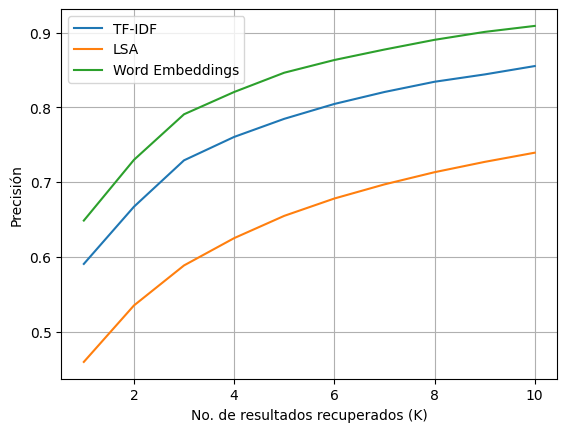


El tiempo total de ejecución ha sido de 1.1070740461349486 minutos.


La precisión de encontrar la frase duplicada como la frase más cercana, para cada método es:
0.5905 0.4594 0.6485

La precisión promedio para cada método es:
[np.float64(0.769), np.float64(0.6416999999999999), np.float64(0.8276399999999999)]

Y el MEJOR RESULTADO PROMEDIO es:
0.8276399999999999


In [11]:
plt.plot(k_range, TFIDF_precisiones, label="TF-IDF")
plt.plot(k_range, LSA_precisiones, label="LSA")
plt.plot(k_range, EMBEDD_precisiones, label="Word Embeddings")
plt.xlabel("No. de resultados recuperados (K)")
plt.ylabel("Precisión")
plt.legend()
plt.grid()
plt.show()

print("\nEl tiempo total de ejecución ha sido de {} minutos.\n".format((time.time() - t_ini)/60))

promedios = [np.mean(TFIDF_precisiones), np.mean(LSA_precisiones), np.mean(Embedd_precisiones)]

print("\nLa precisión de encontrar la frase duplicada como la frase más cercana, para cada método es:")
print(TFIDF_precisiones[0], LSA_precisiones[0], Embedd_precisiones[0])

print("\nLa precisión promedio para cada método es:")
print(promedios)

print("\nY el MEJOR RESULTADO PROMEDIO es:")
print(np.max(promedios))

## Análisis de resultados

### Comparativa de métodos

- **TF-IDF (word + char n-grams)**: Captura coincidencias léxicas exactas y patrones subword. Los char n-grams aportan robustez ante variaciones morfológicas (plural/singular, conjugaciones). Es el baseline más fuerte para coincidencias léxicas.

- **LSA**: Reduce la dimensionalidad de TF-IDF mediante SVD, capturando relaciones semánticas latentes entre términos. Puede encontrar similitudes entre preguntas que usan sinónimos en contextos similares, pero pierde precisión léxica al comprimir la información.

- **Sentence Embeddings (all-mpnet-base-v2)**: Pre-entrenado específicamente para medir similitud semántica entre frases. Captura paráfrasis y equivalencias semánticas que los métodos léxicos no detectan. Debería obtener los mejores resultados porque las preguntas duplicadas en Quora son frecuentemente paráfrasis (misma pregunta con diferentes palabras).